# Calculating R-value from 0, 45, and 90 tensile simulations

In [1]:
import numpy as np
import matflow as mf
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image


In [2]:

workflow_path = Path("Al_rvalues_2025-12-03_105839")
workflow = mf.Workflow(workflow_path)


In [4]:

VE_response_RD = workflow.tasks.simulate_VE_loading_damask.elements[0].iterations[0].outputs.VE_response.value

VE_response_RD45 = workflow.tasks.simulate_VE_loading_damask.elements[1].iterations[0].outputs.VE_response.value

VE_response_TD = workflow.tasks.simulate_VE_loading_damask.elements[2].iterations[0].outputs.VE_response.value

cmap = ["r", "b", "g"]

plastic_idx = 100


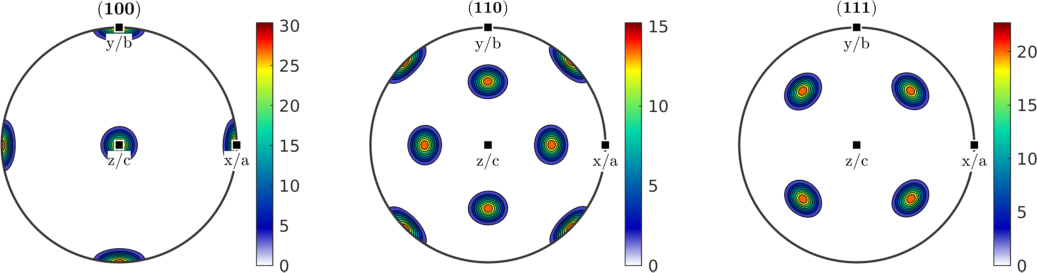

In [5]:

# X0
Image(Path(f"{workflow_path}/execute/t_1/e_0/pole_figure.png"))


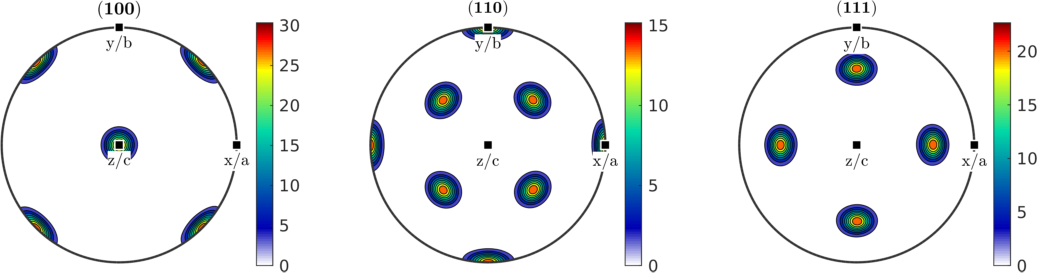

In [6]:

# X45
Image(Path(f"{workflow_path}/execute/t_1/e_1/pole_figure.png"))


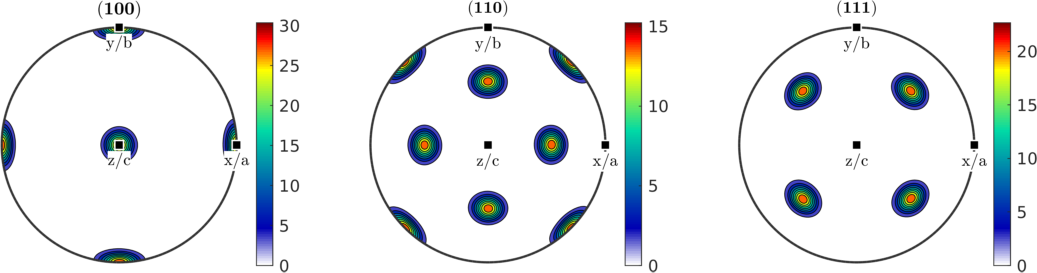

In [7]:

# X90 (Y)
Image(Path(f"{workflow_path}/execute/t_1/e_2/pole_figure.png"))


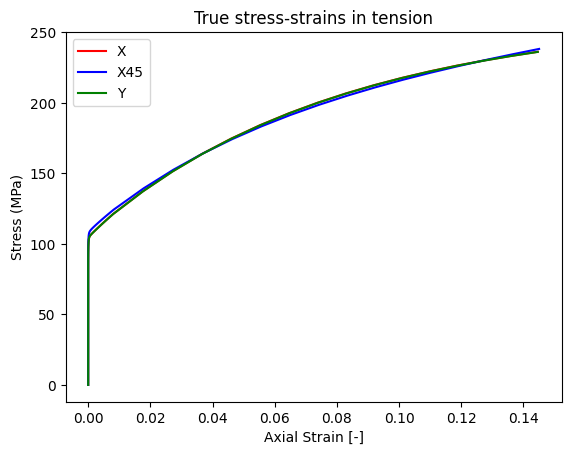

In [8]:

# plot stress-strains
for i, (direction, VE_response) in enumerate({"X":VE_response_RD, "X45":VE_response_RD45, "Y":VE_response_TD}.items()):
    stressX = np.asarray(VE_response['volume_data']['sigma_mean_along_axes_1']['data'][:,0,0])
    stressY = np.asarray(VE_response['volume_data']['sigma_mean_along_axes_1']['data'][:,1,1])
    stressZ = np.asarray(VE_response['volume_data']['sigma_mean_along_axes_1']['data'][:,2,2])

    strainX = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,0,0])
    strainY = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,1,1])
    strainZ = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,2,2])

    plt.plot(strainX, stressX/1e6, label=f"{direction}", color=cmap[i])
plt.title(f"True stress-strains in tension")
plt.xlabel(f"Axial Strain [-]")
plt.ylabel(f"Stress (MPa)")
plt.legend();


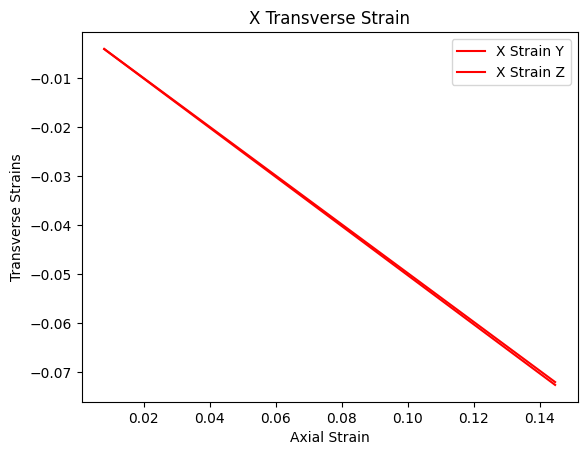

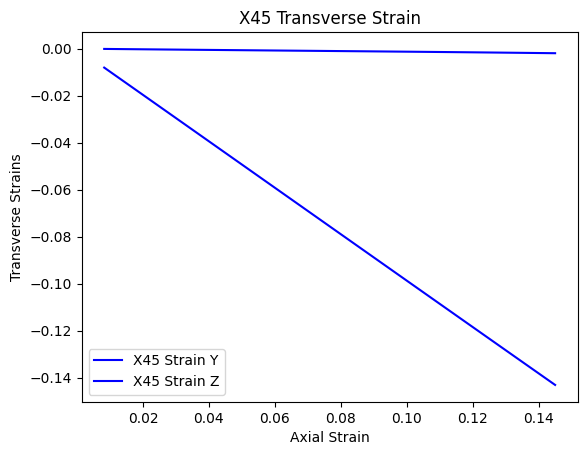

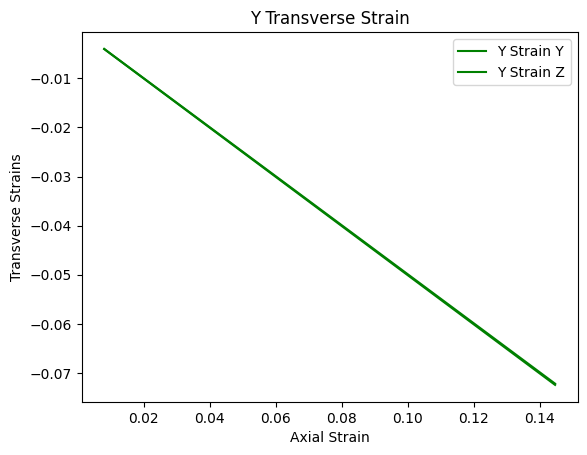

In [9]:

# plot stress-strains
for i, (direction, VE_response) in enumerate({"X":VE_response_RD, "X45":VE_response_RD45, "Y":VE_response_TD}.items()):
    stressX = np.asarray(VE_response['volume_data']['sigma_mean_along_axes_1']['data'][:,0,0])
    stressY = np.asarray(VE_response['volume_data']['sigma_mean_along_axes_1']['data'][:,1,1])
    stressZ = np.asarray(VE_response['volume_data']['sigma_mean_along_axes_1']['data'][:,2,2])

    strainX = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,0,0])
    strainY = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,1,1])
    strainZ = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,2,2])

    plt.figure()
    plt.plot(strainX[plastic_idx:], strainY[plastic_idx:], label=f"{direction} Strain Y", color=cmap[i])
    plt.plot(strainX[plastic_idx:], strainZ[plastic_idx:], label=f"{direction} Strain Z", color=cmap[i])
    plt.title(f"{direction} Transverse Strain")
    plt.ylabel(f"Transverse Strains")
    plt.xlabel(f"Axial Strain")
    plt.legend();


r value X: 0.9920171204223867
r value X45: 0.013547526728021658
r value Y: 1.0032932871712714


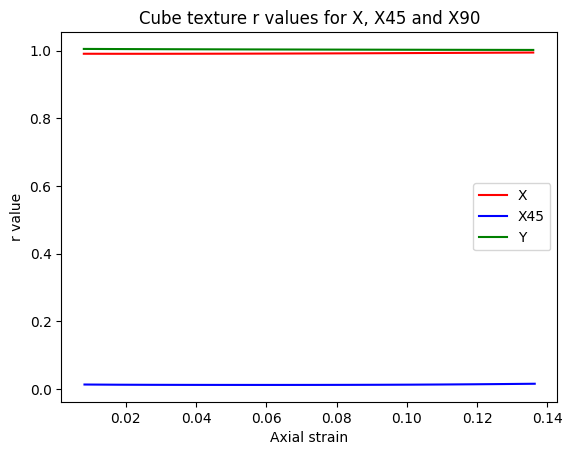

In [10]:

# plot r-values
for i, (direction, VE_response) in enumerate({"X":VE_response_RD, "X45":VE_response_RD45, "Y":VE_response_TD}.items()):
    strainX = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,0,0])
    strainY = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,1,1])
    strainZ = np.asarray(VE_response['volume_data']['epsilon_U^0(F_p)_mean_along_axes_1']['data'][:,2,2])

    rvalue = np.diff(strainY[plastic_idx:]) / np.diff(strainZ[plastic_idx:])
    plt.plot(strainX[100:-1], rvalue, label=f"{direction}", color=cmap[i])
    print(f"r value {direction}: {rvalue.mean()}")
    
# plt.ylim([0, 1.2])
plt.title(f"Cube texture r values for X, X45 and X90")
plt.ylabel(f"r value")
plt.xlabel(f"Axial strain")
plt.legend();
